In [4]:
# -------------------------
# STEP 1: Load + preprocess
# -------------------------
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import joblib
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

data = pd.read_csv('marketing_campaign.csv', delimiter="\t")
pd.set_option("display.max_columns", None)

data.head()


,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [5]:
data.info()

data = data.drop(columns=["ID", "Z_CostContact", "Z_Revenue", ])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [6]:

data['Income'] = data['Income'].fillna(data['Income'].median())
# Combine Kidhome + Teenhome
data["children"] = data["Kidhome"] + data["Teenhome"]
data['Has_Children'] = (data['children'] > 0).astype(int)

# Convert join date, calculate Age
data["Dt_Customer"] = pd.to_datetime(data["Dt_Customer"], dayfirst=True)
data['Age'] = data['Dt_Customer'].max().year - data['Year_Birth']
data['Age'] = data['Age'].clip(lower=18, upper=73)

# Age bins
age_bins = [18, 25, 45, 65, 73]
age_labels = [
    "Young Trend Seekers (18–25)",
    "Value-Oriented Adults (26–45)",
    "Mid-Lifers (46–65)",
    "Mature Elite Shoppers (65+)"
]

data['AgeGroup_Label'] = pd.cut(
    data['Age'],
    bins=age_bins,
    labels=age_labels,
    right=True,
    include_lowest=True
)

age_map = {
    "Young Trend Seekers (18–25)": 0,
    "Value-Oriented Adults (26–45)": 1,
    "Mid-Lifers (46–65)": 2,
    "Mature Elite Shoppers (65+)": 3
}
data['AgeGroup'] = data['AgeGroup_Label'].map(age_map)

# Marital Status cleanup + binning
data['Marital_Status'] = data['Marital_Status'].replace({
    'Married': 'In Relationship',
    'Together': 'In Relationship',
    'Single': 'Single',
    'Divorced': 'Single',
    'Widow': 'Single',
})
data = data[~data['Marital_Status'].isin(['Alone', 'Absurd','YOLO'])].copy()
data['Marital_Status'] = data['Marital_Status'].map({
    'In Relationship': 1,
    'Single': 0
})

# Purchases / Spending / Campaigns
data["Purchases"] =  data[[
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases"
]].sum(axis=1)
data["Spending"] = data[[
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"
]].sum(axis=1)
data["Effective_Campaigns"] = data[[
    "AcceptedCmp1", "AcceptedCmp2", "AcceptedCmp3", "AcceptedCmp4", "AcceptedCmp5"
]].sum(axis=1)

# Education binning
data['Education'] = data['Education'].replace(
    ['PhD', 'Master', "Graduation"], "Graduated"
)
le_education = LabelEncoder()
data['Education_Encoded'] = le_education.fit_transform(data['Education'])

In [7]:
# --- Drop only unused columns (KEEP NumWebVisitsMonth) ---
data = data.drop(columns=[
    "Kidhome", "Teenhome",
    "NumDealsPurchases","NumWebPurchases","NumCatalogPurchases","NumStorePurchases",
    "MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds",
    "AcceptedCmp1","AcceptedCmp2","AcceptedCmp3","AcceptedCmp4","AcceptedCmp5",
    "Year_Birth","Dt_Customer","Education", "Age"
])



In [8]:
data.head()

,Marital_Status,Income,Recency,NumWebVisitsMonth,Complain,Response,children,Has_Children,AgeGroup_Label,AgeGroup,Purchases,Spending,Effective_Campaigns,Education_Encoded
0,0,58138.0,58,7,0,1,0,0,Mid-Lifers (46–65),2,25,1617,0,2
1,0,46344.0,38,5,0,0,2,1,Mid-Lifers (46–65),2,6,27,0,2
2,1,71613.0,26,4,0,0,0,0,Mid-Lifers (46–65),2,21,776,0,2
3,1,26646.0,26,6,0,0,1,1,Value-Oriented Adults (26–45),1,8,53,0,2
4,1,58293.0,94,5,0,0,1,1,Value-Oriented Adults (26–45),1,19,422,0,2


In [59]:
# --- Feature Groups ---
demo_features = ["AgeGroup", "Education_Encoded", "Marital_Status", "Has_Children"]
behavior_features = ["Purchases", "Spending"]  # ✅ kept
loyalty_features = ["Recency", "Response"]

cluster_features = behavior_features + loyalty_features



In [60]:
# Scale + Cluster
X = data[cluster_features]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)



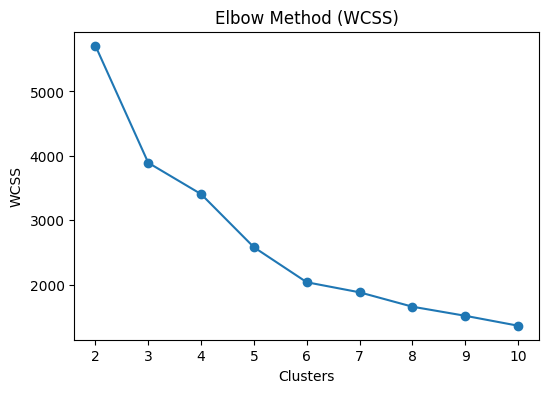

In [61]:
wcss, sil_scores = [], []
for k in range(2, 11):
    km = KMeans(n_clusters=k, random_state=42)
    labels = km.fit_predict(X_scaled)
    wcss.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

# Elbow
plt.figure(figsize=(6,4))
plt.plot(range(2,11), wcss, marker="o")
plt.title("Elbow Method (WCSS)")
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.show()


In [62]:
kmeans = KMeans(n_clusters=4, random_state=42)
data["Cluster"] = kmeans.fit_predict(X_scaled)
sil_score = silhouette_score(X_scaled, data["Cluster"])
print(f"Silhouette Score: {sil_score:.3f}")


Silhouette Score: 0.417


In [63]:
# Save
joblib.dump(kmeans, "kmeans_model.pkl")

['kmeans_model.pkl']

In [64]:
cluster_profiles = data.groupby("Cluster")[cluster_features].mean()
print(cluster_profiles)

cluster_labels = {
    0: "High Spenders",
    1: "Budget-Conscious",
    2: "Trend Seekers",
    3: "Loyal Mid-Lifers"
}
data["Cluster_Label"] = data["Cluster"].map(cluster_labels)

         Purchases     Spending    Recency  Response
Cluster                                             
0        21.704762  1060.332143  52.569048       0.0
1         8.545198   126.370998  50.775895       0.0
2        12.045113   233.691729  28.203008       1.0
3        21.540404  1500.095960  40.247475       1.0


In [65]:
print("Cluster sizes:\n", data["Cluster"].value_counts())
cluster_sizes = data["Cluster"].value_counts()
print("\nCluster means:\n", data.groupby("Cluster")[cluster_features].mean())

# --- Numeric summary ---
numeric_demo = [col for col in demo_features if pd.api.types.is_numeric_dtype(data[col])]
numeric_summary = data.groupby("Cluster")[numeric_demo].mean()

# Cluster features (behavior + loyalty)
cluster_means = data.groupby("Cluster")[cluster_features].mean()

# Combine numeric profiles
cluster_profile = pd.concat([cluster_means, numeric_summary], axis=1)
print("\nCluster numeric profile (means):")
print(cluster_profile)

# --- Categorical summary ---
categorical_demo = [col for col in demo_features if col not in numeric_demo]
print("\nCluster categorical profile (proportions):")
for col in categorical_demo:
    print(f"\n{col}:")
    print(data.groupby("Cluster")[col].value_counts(normalize=True).unstack().round(2))


Cluster sizes:
 Cluster
1    1062
0     840
3     198
2     133
Name: count, dtype: int64

Cluster means:
          Purchases     Spending    Recency  Response
Cluster                                             
0        21.704762  1060.332143  52.569048       0.0
1         8.545198   126.370998  50.775895       0.0
2        12.045113   233.691729  28.203008       1.0
3        21.540404  1500.095960  40.247475       1.0

Cluster numeric profile (means):
         Purchases     Spending    Recency  Response  Education_Encoded  \
Cluster                                                                   
0        21.704762  1060.332143  52.569048       0.0           1.836905   
1         8.545198   126.370998  50.775895       0.0           1.739171   
2        12.045113   233.691729  28.203008       1.0           1.849624   
3        21.540404  1500.095960  40.247475       1.0           1.868687   

         Marital_Status  Has_Children  
Cluster                                
0         

In [66]:
# --- Numeric summary ---
numeric_demo = [col for col in demo_features if pd.api.types.is_numeric_dtype(data[col])]
numeric_summary = data.groupby("Cluster")[numeric_demo].mean()

# Cluster features (behavior + loyalty)
cluster_means = data.groupby("Cluster")[cluster_features].mean()

# Combine numeric profiles
cluster_profile = pd.concat([cluster_means, numeric_summary], axis=1)
print("\nCluster numeric profile (means):")
print(cluster_profile)

# --- Categorical summary ---
categorical_demo = [col for col in demo_features if col not in numeric_demo]
print("\nCluster categorical profile (proportions):")
for col in categorical_demo:
    print(f"\n{col}:")
    print(data.groupby("Cluster")[col].value_counts(normalize=True).unstack().round(2))


Cluster numeric profile (means):
         Purchases     Spending    Recency  Response  Education_Encoded  \
Cluster                                                                   
0        21.704762  1060.332143  52.569048       0.0           1.836905   
1         8.545198   126.370998  50.775895       0.0           1.739171   
2        12.045113   233.691729  28.203008       1.0           1.849624   
3        21.540404  1500.095960  40.247475       1.0           1.868687   

         Marital_Status  Has_Children  
Cluster                                
0              0.689286      0.608333  
1              0.665725      0.869115  
2              0.503759      0.864662  
3              0.459596      0.242424  

Cluster categorical profile (proportions):

AgeGroup:
AgeGroup     0     1     2     3
Cluster                         
0         0.04  0.43  0.49  0.05
1         0.04  0.57  0.37  0.02
2         0.02  0.68  0.29  0.01
3         0.06  0.44  0.42  0.07


In [67]:
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
y = data["Cluster"]

# 1️⃣ Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2️⃣ Select numeric features
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

# 3️⃣ Preprocessing
preprocessor = ColumnTransformer(
    transformers=[("num", StandardScaler(), numeric_features)]
)

# 4️⃣ Define multiple models
models = {
    "RandomForest": RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        max_features='sqrt',
        min_samples_leaf=2,
        random_state=42
    ),
    "GradientBoosting": GradientBoostingClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    ),
    "LogisticRegression": LogisticRegression(
        max_iter=1000,
        random_state=42
    )
}

# 5️⃣ Train and evaluate each model
for name, model in models.items():
    print(f"\n===== {name} =====")
    clf = Pipeline(steps=[("preprocessor", preprocessor), ("classifier", model)])
    clf.fit(X_train, y_train)

    # Test set evaluation
    y_pred = clf.predict(X_test)
    print("Test Accuracy:", accuracy_score(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

    # Cross-validation
    cv_scores = cross_val_score(clf, X, y, cv=5)
    print("\nCross-Validation Scores:", cv_scores)
    print("Mean CV Accuracy:", cv_scores.mean())


===== RandomForest =====
Test Accuracy: 0.9977628635346756

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       168
           1       1.00      1.00      1.00       212
           2       0.96      1.00      0.98        27
           3       1.00      0.97      0.99        40

    accuracy                           1.00       447
   macro avg       0.99      0.99      0.99       447
weighted avg       1.00      1.00      1.00       447


Confusion Matrix:
 [[168   0   0   0]
 [  0 212   0   0]
 [  0   0  27   0]
 [  0   0   1  39]]

Cross-Validation Scores: [0.99105145 0.98881432 0.99552573 0.9955157  0.99327354]
Mean CV Accuracy: 0.9928361473099188

===== GradientBoosting =====
Test Accuracy: 0.9955257270693513

Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       168
           1       1.00      1.00      1.00       212
           

In [68]:
# Sample customers
sample_customers = pd.DataFrame([
    {
        "AgeGroup": 2,
        "Marital_Status": 1,
        "Education_Encoded": 1,
        "children": 1,
        "Has_Children": 1,
        "Purchases": 8.5,
        "Spending": 126,
        "Effective_Campaigns": 2,
        "Recency": 50,
        "Response": 50,
        "NumWebVisitsMonth": 5
    },
    {
        "AgeGroup": 0,
        "Marital_Status": 0,
        "Education_Encoded": 0,
        "children": 2,
        "Has_Children": 1,
        "Purchases": 3,
        "Spending": 120,
        "Effective_Campaigns": 0,
        "Recency": 80,
        "Response": 0,
        "NumWebVisitsMonth": 12
    }
])

# Predict clusters
pred_clusters = clf.predict(sample_customers)
sample_customers["Predicted_Cluster"] = pred_clusters
sample_customers["Cluster_Label"] = sample_customers["Predicted_Cluster"].map(cluster_labels)

print(sample_customers[[
     "AgeGroup", "Purchases", "Spending", "Predicted_Cluster", "Cluster_Label"
]])


   AgeGroup  Purchases  Spending  Predicted_Cluster     Cluster_Label
0         2        8.5       126                  2     Trend Seekers
1         0        3.0       120                  1  Budget-Conscious


In [69]:
categorical_demo = ["AgeGroup", "Marital_Status", "Has_Children", "Education_Encoded"]

cat_props = []
for col in categorical_demo:
    prop = (
        data.groupby('Cluster')[col]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .rename(columns=lambda c: f"P({col}={c})")
        .round(2)
    )
    cat_props.append(prop)

cluster_profile = pd.concat([cluster_means, cluster_sizes.rename('Count')] + cat_props, axis=1)
print(cluster_profile)


         Purchases     Spending    Recency  Response  Count  P(AgeGroup=0)  \
Cluster                                                                      
0        21.704762  1060.332143  52.569048       0.0    840           0.04   
1         8.545198   126.370998  50.775895       0.0   1062           0.04   
2        12.045113   233.691729  28.203008       1.0    133           0.02   
3        21.540404  1500.095960  40.247475       1.0    198           0.06   

         P(AgeGroup=1)  P(AgeGroup=2)  P(AgeGroup=3)  P(Marital_Status=0)  \
Cluster                                                                     
0                 0.43           0.49           0.05                 0.31   
1                 0.57           0.37           0.02                 0.33   
2                 0.68           0.29           0.01                 0.50   
3                 0.44           0.42           0.07                 0.54   

         P(Marital_Status=1)  P(Has_Children=0)  P(Has_Children=1)  

In [70]:
# The descriptive profiles were chosen based on the numeric characteristics of each cluster:
# - Cluster 0: High Purchases (21.7) and Spending (1060), high proportion married (0.69) and has children (0.61) → "Wealthy, Family-Focused".
# - Cluster 1: Low Purchases (8.5) and Spending (126), high proportion with children (0.87) → "Budget-Savvy Family".
# - Cluster 2: Moderate Purchases (12) and Spending (234), youngest age group dominates (P(AgeGroup=0)=0.68), high Response (1.0) → "Young Trend Seekers".
# - Cluster 3: High Purchases (21.5) and very high Spending (1500), moderate age, lower proportion with children (0.24), high Response (1.0) → "Loyal, Family-Oriented".
# This approach combines spending/behavior metrics with key demographic indicators (AgeGroup, Has_Children, Marital_Status) to make the profiles intuitive and actionable.

def descriptive_profile(row):
    # Cluster 0: High Spenders
    if row['Cluster_Label'] == "High Spenders":
        if row['Has_Children'] == 1:
            # Most in this cluster are mid-age, married/in-relationship, with children → Wealthy, Family-Focused
            return "Wealthy, Family-Focused"
        else:
            # High spending but single / no children → Wealthy, Single / No Children
            return "Wealthy, Single / No Children"

    # Cluster 1: Budget-Conscious
    elif row['Cluster_Label'] == "Budget-Conscious":
        if row['Has_Children'] == 1:
            # Mostly value-oriented adults with children → Budget-Savvy Family
            return "Budget-Savvy Family"
        else:
            # Single, low-spending adults → Budget-Conscious Single
            return "Budget-Conscious Single"

    # Cluster 2: Trend Seekers
    elif row['Cluster_Label'] == "Trend Seekers":
        if row['AgeGroup'] == 0:
            # Young (18-25) singles → Young Trend Seekers
            return "Young Trend Seekers"
        else:
            # Older Trend Seekers → Trend-Seeking Adult
            return "Trend-Seeking Adult"

    # Cluster 3: Loyal Mid-Lifers
    elif row['Cluster_Label'] == "Loyal Mid-Lifers":
        if row['Has_Children'] == 1:
            # Older, loyal, many have children → Loyal, Family-Oriented
            return "Loyal, Family-Oriented"
        else:
            # Older, loyal, single → Loyal Adult / No Children
            return "Loyal Adult / No Children"

    # Catch-all for anything else
    else:
        return row['Cluster_Label'] + " - Other"

# Apply to sample_customers
sample_customers["Profile_Label"] = sample_customers.apply(descriptive_profile, axis=1)

# Show final table
print(sample_customers[[
    "AgeGroup", "Purchases", "Spending", "Predicted_Cluster", "Cluster_Label", "Profile_Label"
]])


   AgeGroup  Purchases  Spending  Predicted_Cluster     Cluster_Label  \
0         2        8.5       126                  2     Trend Seekers   
1         0        3.0       120                  1  Budget-Conscious   

         Profile_Label  
0  Trend-Seeking Adult  
1  Budget-Savvy Family  


In [71]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import joblib

# 1. Define pipeline
cluster_pipeline = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("kmeans", KMeans(n_clusters=4, random_state=42))
])

# 2. Train it
cluster_pipeline.fit(X)   # X = your feature dataframe

# 3. Save the trained pipeline (this contains the trained scaler + trained kmeans model)
joblib.dump(cluster_pipeline, "customer_segmentation_model.pkl")

print("✅ Training model saved as customer_segmentation_model.pkl")

✅ Training model saved as customer_segmentation_model.pkl
